In [2]:
import numpy as np
import pandas as pd
import arviz as az
from scipy import stats
from matplotlib import pyplot as plt
from matplotlib import patches
from cmdstanpy import CmdStanModel
from sampler import CycloneSampler, CycloneDataSimulator

In [34]:
def plot_parameter_estimation_stan(draws_df, DataSimulator, param_names, N_obs, save_file=None):

    # save real parameters
    true_params = [
        DataSimulator.sig2,
        DataSimulator.Beta,
        DataSimulator.tau2,
        DataSimulator.alpha, 
        DataSimulator.gamma,
        DataSimulator.nu,
        DataSimulator.lam
    ]

    true_params_flat = np.concatenate([np.atleast_1d(p).flatten() for p in true_params])

    # plot convergence for large data set
    all_param_draws = []
    unscaled_param_draws = []
    param_stds = []
    for param, true in zip(param_names, true_params_flat):
        # normalizes the draws so that they can all be plotted together
        draws = draws_df[param].values[:]
        unscaled_param_draws.append(draws)
        standardized_draws = (draws - true) / draws.std()
        all_param_draws.append(standardized_draws)
        param_stds.append(draws.std())

    # I got help from Claude to make this plot because I didn't know how to plot all the parameters together in a nice way
    fig = plt.figure(figsize=(14, 7))
    fig.suptitle(f"Convergence of Posterior Parameter Draws in Stan, n={N_obs} simulated observations",
                fontsize=13, fontweight='bold', y=1.01)
    ax = fig.add_subplot(111)

    # --- Boxplot ---
    ax.boxplot(
        all_param_draws,
        tick_labels=param_names,
        whis=(5, 95),
        showfliers=False,
        # showmeans=True,
        # meanprops=dict(marker='x', markeredgecolor='black', markersize=6, markeredgewidth=1.5),
        medianprops=dict(color='steelblue', linewidth=1.5),
        boxprops=dict(color='steelblue'),
        whiskerprops=dict(color='steelblue'),
        capprops=dict(color='steelblue'),
    )
    ax.axhline(0, color='red', linestyle='--', linewidth=1, label='True value')
    ax.set_ylabel("Std. Deviations from True Value", fontsize=10)
    ax.tick_params(axis='x', rotation=90)
    ax.legend(fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.set_xlim(0.5, len(param_names) + 0.5)
    
    if save_file is not None: plt.savefig(save_file, dpi=300)
    plt.show()

    return true_params_flat, np.array(unscaled_param_draws)


def plot_parameter_estimation_mcmc(Sampler, DataSimulator, param_names, N_obs, save_file=None):
    N_samples = len(Sampler.alpha_draws)

    # save real parameters
    true_params = [
        DataSimulator.sig2,
        DataSimulator.Beta,
        DataSimulator.tau2,
        DataSimulator.alpha, 
        DataSimulator.gamma,
        DataSimulator.nu,
        DataSimulator.lam
    ]
    true_params_flat = np.concatenate([np.atleast_1d(p).flatten() for p in true_params])
    all_param_draws = np.vstack([
        Sampler.sig2_draws.T,
        Sampler.Beta_draws.reshape(N_samples, -1).T,
        Sampler.tau2_draws.T,
        Sampler.alpha_draws, 
        Sampler.gamma_draws,
        Sampler.nu_draws.T,
        Sampler.lam_draws.T,
    ])

    unscaled_param_draws = all_param_draws.copy()

    param_stds = all_param_draws.std(axis=1)
    all_param_draws = ((all_param_draws.T - true_params_flat) / param_stds).T

    # I got help from Claude to make this plot because I didn't know how to plot all the parameters together in a nice way
    fig = plt.figure(figsize=(14, 7))
    
    ax = fig.add_subplot(111)
    ax.set_title(f"Convergence of Posterior Parameter Draws in MCMC, n={N_obs} simulated observations",
                fontsize=13, fontweight='bold', y=1.01)

    # --- Boxplot ---
    ax.boxplot(
        all_param_draws.T,
        tick_labels=param_names,
        whis=(5, 95),
        showfliers=False,
        medianprops=dict(color='steelblue', linewidth=1.5),
        boxprops=dict(color='steelblue'),
        whiskerprops=dict(color='steelblue'),
        capprops=dict(color='steelblue'),
    )
    ax.axhline(0, color='red', linestyle='--', linewidth=1, label='True value')
    ax.set_ylabel("Std. Deviations from True Value", fontsize=10)
    ax.tick_params(axis='x', rotation=90)
    ax.legend(fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.set_xlim(0.5, len(param_names) + 0.5)
    
    if save_file is not None: plt.savefig(save_file, dpi=300)
    plt.show()

    return true_params_flat, unscaled_param_draws


def compare_posterior_draws(MCMC_draws, Stan_draws, true_params, param_names, figsize=(14, 7), y_lim=(-8, 8), save_file=None):

    n_params = len(MCMC_draws)
    positions = np.arange(n_params)
    labels = ["MCMC Draws", "Stan Draws"]

    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111)

    for i, (mcmc_draw, stan_draw) in enumerate(zip(MCMC_draws, Stan_draws)):

        if true_params is not None:
            ref_val = true_params[i]
            # offset plot slightly left/right from the reference
            vp_mcmc = ax.violinplot([mcmc_draw - ref_val], 
                                    positions=[i-0.15], widths=0.25, showmeans=True, showmedians=False, showextrema=False)
            vp_stan = ax.violinplot([stan_draw - ref_val], 
                                    positions=[i+0.15], widths=0.25, showmeans=True, showmedians=False, showextrema=False)
        else:
            vp_mcmc = ax.violinplot([mcmc_draw], 
                                    positions=[i-0.15], widths=0.25, showmeans=True, showmedians=False, showextrema=False)
            vp_stan = ax.violinplot([stan_draw], 
                                    positions=[i+0.15], widths=0.25, showmeans=True, showmedians=False, showextrema=False)            
        
        # style the violin plots for each sampler
        for pc in vp_mcmc["bodies"]:
            pc.set_facecolor("#1f77b4")
            pc.set_alpha(0.5)
        vp_mcmc["cmeans"].set_color("#1f77b4")

        for pc in vp_stan["bodies"]:
            pc.set_facecolor("#ff7f0e")
            pc.set_alpha(0.5)
        vp_stan["cmeans"].set_color("#ff7f0e")

    # mark the reference values (0 because we centered the plot)
    if true_params is not None: ax.axhline(0, color="black", linewidth=1.2, linestyle="--", label="True value", zorder=5)

    # set ticks and labels
    ax.set_xticks(positions)
    ax.set_xticklabels(param_names, rotation=90)
    if true_params is not None: ax.set_ylabel("Deviation from True Value")
    else: ax.set_ylabel("Parameter Value")
    ax.set_title("Posterior Sample Comparison")

    ax.set_ylim(*y_lim)

    if true_params is not None:
        legend_handles = [
            patches.Patch(color='#1f77b4', alpha=0.7, label=labels[0]),
            patches.Patch(color='#ff7f0e', alpha=0.7, label=labels[1]),
            plt.Line2D([0], [0], color='black', linestyle='--', label='True value')
        ]
    else: 
        legend_handles = [
            patches.Patch(color='#1f77b4', alpha=0.7, label=labels[0]),
            patches.Patch(color='#ff7f0e', alpha=0.7, label=labels[1]),
        ]


    ax.legend(handles=legend_handles, loc="upper left")
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    if save_file is not None: plt.savefig(save_file, dpi=300)
    return fig, ax

Test whether our MCMC implementation converges to the same parameters as the Stan model when given simulated data.

In [238]:
# prior parameters (for sampling data)
a = 3
y_alpha = 3
z_alpha = 2
y_gamma = 3
z_gamma = 2 
v2 = 2
y_lam = 3
z_lam = 1

# model parameters
B = 3               # number of ocean basins
D = 5               # number of predictors

In [239]:
param_names = [f"sig2[{b}]" for b in range(1, B+1)] + [f"Beta[{b},{d}]" for b in range(1, B+1) for d in range(1, D+1)] + [f"tau2[{d}]" for d in range(1, D+1)] + ["alpha", "gamma"] + [f"nu[{d}]" for d in range(1, D+1)] + [f"lambda[{d}]" for d in range(1, D+1)]

In [28]:
N = 1000             # number of observations

# simulate N observations from the model
DataSimulator = CycloneDataSimulator(
    B = B,
    a = a,
    y_alpha=y_alpha, z_alpha=z_alpha,
    y_gamma=y_gamma, z_gamma=z_gamma,
    v2=v2,
    y_lam=y_lam, z_lam=z_lam
)
DataSimulator.generate_X(N_sim=N)
X = DataSimulator.X 
basins = DataSimulator.basins
W = DataSimulator.simulate()

# save real parameters
real_params = [
    DataSimulator.sig2,
    DataSimulator.Beta,
    DataSimulator.tau2,
    DataSimulator.alpha, 
    DataSimulator.gamma,
    DataSimulator.nu,
    DataSimulator.lam
]

# load simulated data into a Stan dictionary
stan_basins = basins + 1            # Stan is 1-indexed!!!
stan_data = {
    "N" : N, "B" : B, "D" : D,
    "W" : W, "X" : X, "basins" : stan_basins,
    "a" : a,
    "y_alpha" : y_alpha, "z_alpha" : z_alpha,
    "y_gamma" : y_gamma, "z_gamma" : z_gamma,
    "v2" : v2,
    "y_lambda" : y_lam, "z_lambda" : z_lam,
}

In [29]:
# load Stan sampler
StanSampler = CmdStanModel(stan_file="conjugate_model.stan")

# initialize our own MCMC sampler
MCMCSampler = CycloneSampler(
    W = W, X = X, basins = basins,
    a=a,
    y_alpha=y_alpha, z_alpha=z_alpha,
    y_gamma=y_gamma, z_gamma=z_gamma, 
    y_lam=y_lam, z_lam=z_lam,
    v2=v2,
    B=B
)

In [242]:
# sample using Stan
fit = StanSampler.sample(stan_data, iter_warmup=1000, iter_sampling=5_000)
stan_draws_df = fit.draws_pd()

23:43:57 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/6000 [00:00<?, ?it/s, (Warmup)]




chain 1:   2%|▏         | 100/6000 [00:02<02:21, 41.82it/s, (Warmup)]


chain 1:   3%|▎         | 200/6000 [00:03<01:33, 62.04it/s, (Warmup)]


chain 1:   5%|▌         | 300/6000 [00:04<01:14, 76.21it/s, (Warmup)]


chain 1:   7%|▋         | 400/6000 [00:05<01:02, 90.32it/s, (Warmup)]


chain 1:   8%|▊         | 500/6000 [00:06<00:57, 95.16it/s, (Warmup)]


chain 1:  12%|█▏        | 700/6000 [00:10<01:44, 50.70it/s, (Warmup)] 


chain 1:  13%|█▎        | 800/6000 [00:11<01:20, 64.60it/s, (Warmup)]


chain 1:  15%|█▌        | 900/6000 [00:12<01:05, 78.15it/s, (Warmup)]




chain 1:  17%|█▋        | 1000/6000 [00:13<00:57, 86.68it/s, (Sampling)]



chain 1:  18%|█▊        | 1100/6000 [00:14<00:51, 95.14it/s, (Sampling)]



chain 1:  20%|██        | 1200/6000 [00:14<00:47, 101.34it/s, (Sampling)]


chain 1:  22%|██▏       | 1300/6000 [00:15<00:43, 107.61it/s, (Sampling)]



23:44:57 - cmdstanpy - INFO - CmdStan done processing.
23:44:57 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: inv_gamma_lpdf: Shape parameter is inf, but must be positive finite! (in 'conjugate_model.stan', line 46, column 4 to column 35)
Exception: multi_normal_lpdf: LDLT_Factor of covariance parameter is not positive definite.  last conditional variance is -nan. (in 'conjugate_model.stan', line 48, column 8 to column 93)
Exception: multi_normal_lpdf: LDLT_Factor of covariance parameter is not positive definite.  last conditional variance is -nan. (in 'conjugate_model.stan', line 48, column 8 to column 93)
Exception: inv_gamma_lpdf: Shape parameter is 0, but must be positive finite! (in 'conjugate_model.stan', line 46, column 4 to column 35)
Consider re-running with show_console=True if the above output is unclear!


In [30]:
MCMCSampler.sample(30_000, init_state=real_params)

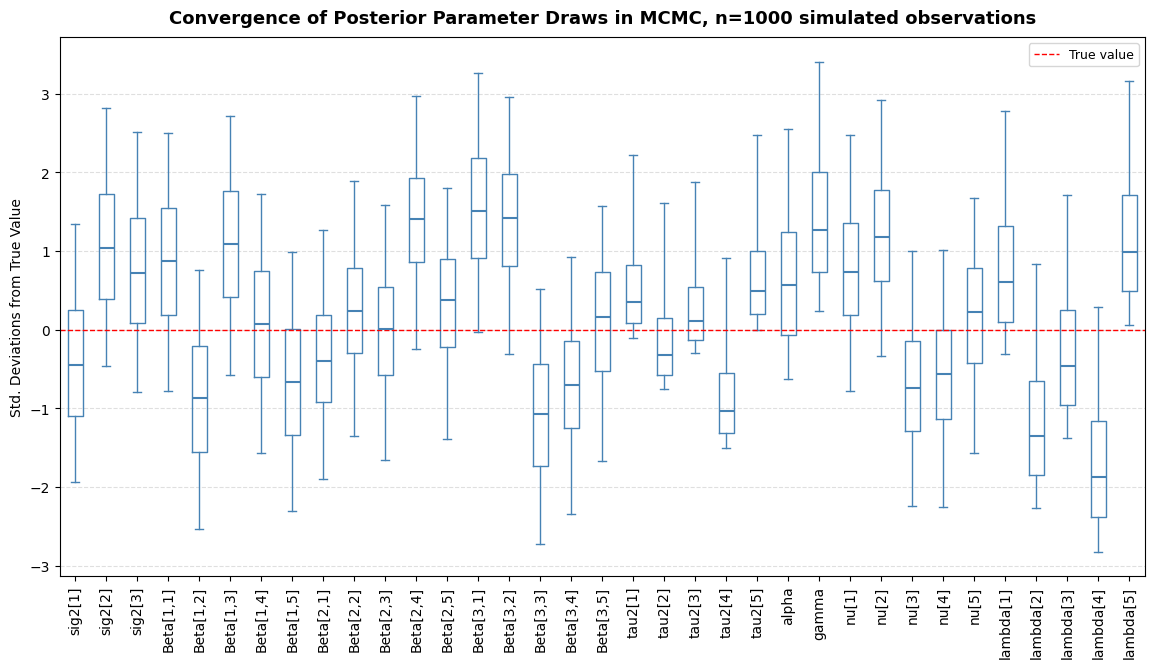

In [35]:
true_params, MCMC_draws = plot_parameter_estimation_mcmc(MCMCSampler, DataSimulator, param_names, N,
                                                         save_file="../figures/MCMC_coverage.png")
# _, Stan_draws = plot_parameter_estimation_stan(stan_draws_df, DataSimulator, param_names, N,
#                                                save_file="../figures/Stan_coverage.png")

(<Figure size 1400x700 with 1 Axes>,
 <Axes: title={'center': 'Posterior Sample Comparison'}, ylabel='Deviation from True Value'>)

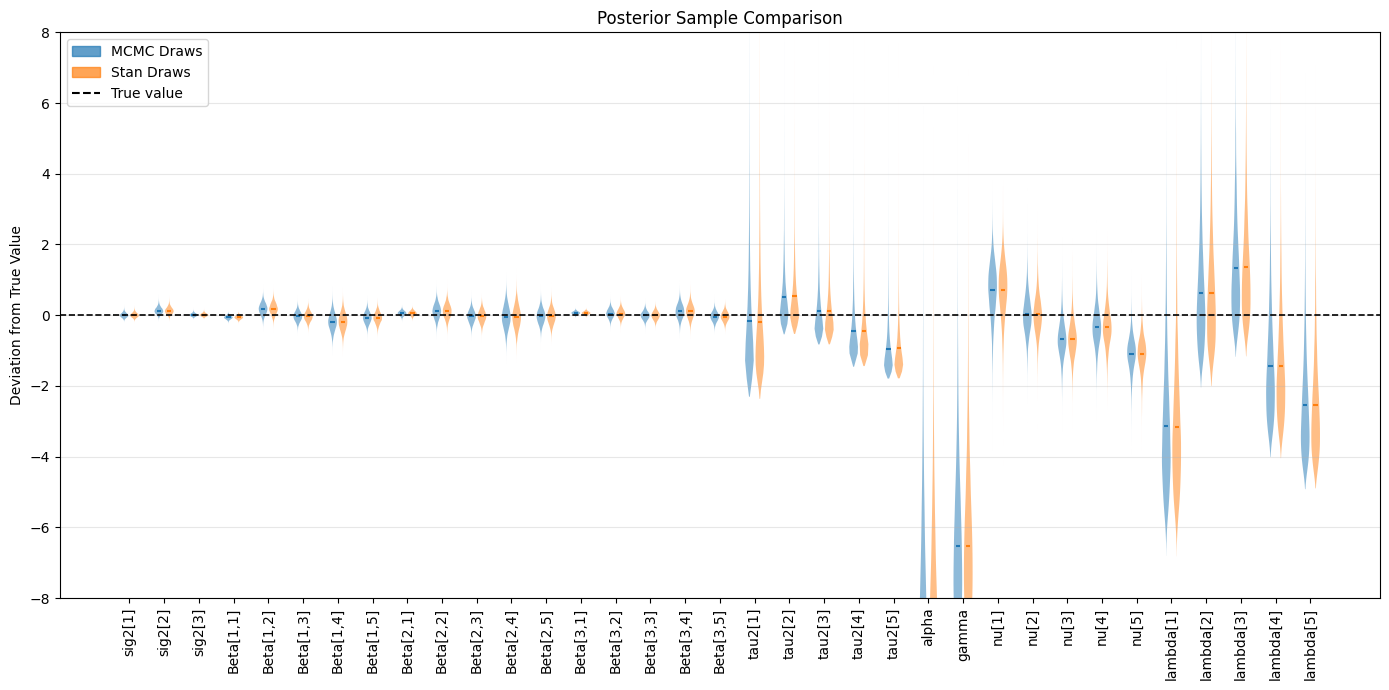

In [248]:
compare_posterior_draws(MCMC_draws, Stan_draws, true_params, param_names, save_file="../figures/parameter_comparison_simulated.png")

Before testing the models on real data, use the data simulator to look for good prior parameters.
Without looking at the data:
- Info I found on Google tells me that tropical typhoons have max wind speeds above 65 knots, with major tropical cyclones sometimes recording wind speeds up to 120 knots. Since we are assuming the log of the max wind speed is normally distributed, I want to choose prior parameters consistent with producting a normal distribution centered around roughly 4.5 (log(90)).

In [17]:
# calibrated prior parameters
a = 3.
y_alpha, z_alpha = 2., 3./2.
y_gamma, z_gamma = 2., 4.
v2 = 100.
y_lam, z_lam = 2., 25.

# model parameters
B = 3               # number of ocean basins
D = 5               # number of predictors

N = 1000             # number of observations

# simulate N observations from the model
CalibratedDataSimulator = CycloneDataSimulator(
    B = B,
    a = a,
    y_alpha=y_alpha, z_alpha=z_alpha,
    y_gamma=y_gamma, z_gamma=z_gamma,
    v2=v2,
    y_lam=y_lam, z_lam=z_lam
)
CalibratedDataSimulator.generate_X(N_sim=N)
X = CalibratedDataSimulator.X 
basins = CalibratedDataSimulator.basins
W = CalibratedDataSimulator.simulate()

# save real parameters
real_params = [
    CalibratedDataSimulator.sig2,
    CalibratedDataSimulator.Beta,
    CalibratedDataSimulator.tau2,
    CalibratedDataSimulator.alpha, 
    CalibratedDataSimulator.gamma,
    CalibratedDataSimulator.nu,
    CalibratedDataSimulator.lam
]

# load simulated data into a Stan dictionary
stan_basins = basins + 1            # Stan is 1-indexed!!!
stan_data = {
    "N" : N, "B" : B, "D" : D,
    "W" : W, "X" : X, "basins" : stan_basins,
    "a" : a,
    "y_alpha" : y_alpha, "z_alpha" : z_alpha,
    "y_gamma" : y_gamma, "z_gamma" : z_gamma,
    "v2" : v2,
    "y_lambda" : y_lam, "z_lambda" : z_lam,
}

Compare convergence of Stan and MCMC on real data.

In [3]:
# load data 
data = pd.read_csv("../processed_data/processed_data.csv")
# create basin index column
data["BasinIDX"] = data[["AL", "CP", "EP"]].values.argmax(axis=1)
predictor_cols = ["ONI", "logVMAX12", "MSLP12", "POT12", "VGRAD6-12"]     # are these the right columns??
X, W = data[predictor_cols].to_numpy(), data["logVMAX36"].to_numpy()
basins = data["BasinIDX"].to_numpy()
stan_basins = basins + 1

In [18]:
# calibrated prior parameters
a = 3.
y_alpha, z_alpha = 2., 3./2.
y_gamma, z_gamma = 2., 4.
v2 = 100.
y_lam, z_lam = 2., 25.

# model parameters
B = len(set(stan_basins))               # number of ocean basins
D = X.shape[1]                          # number of predictors
N = len(W)                              # number of observations

# data for Stan
stan_data = {
    "N" : int(N), "B" : int(B), "D" : int(D),
    "W" : W, "X" : X, "basins" : stan_basins,
    "a" : a,
    "y_alpha" : y_alpha, "z_alpha" : z_alpha,
    "y_gamma" : y_gamma, "z_gamma" : z_gamma,
    "v2" : v2,
    "y_lambda" : y_lam, "z_lambda" : z_lam,
}

In [5]:
param_names = [f"sig2[{b}]" for b in range(1, B+1)] + [f"Beta[{b},{d}]" for b in range(1, B+1) for d in range(1, D+1)] + [f"tau2[{d}]" for d in range(1, D+1)] + ["alpha", "gamma"] + [f"nu[{d}]" for d in range(1, D+1)] + [f"lambda[{d}]" for d in range(1, D+1)]

In [6]:
# load Stan sampler
StanSampler = CmdStanModel(stan_file="conjugate_model.stan")

In [10]:
# sample using Stan
fit = StanSampler.sample(stan_data, iter_warmup=500, iter_sampling=5000, chains=2)
stan_draws_df = fit.draws_pd()

14:32:52 - cmdstanpy - INFO - CmdStan start processing


chain 2: 100%|██████████| 5500/5500 [05:41<00:00, 16.11it/s, (Sampling completed)]


14:38:34 - cmdstanpy - INFO - CmdStan done processing.
14:38:34 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: inv_gamma_lpdf: Scale parameter is 0, but must be positive finite! (in 'conjugate_model.stan', line 46, column 4 to column 35)
Consider re-running with show_console=True if the above output is unclear!


14:38:35 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 4999 iterations at max treedepth (100.0%)
	Chain 2 had 4999 iterations at max treedepth (100.0%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.


In [13]:
# extract stan data to an array
stan_draws_array = []
stan_stds = []
for param in param_names:
    # normalizes the draws so that they can all be plotted together
    draws = stan_draws_df[param]
    stan_draws_array.append(draws)
    stan_stds.append(draws.std())


In [12]:
stan_draws_df.to_csv("../posterior_draws/conjugate_stan_model_posterior_draws.csv")

In [19]:
# fit the data using our MCMC implementation

init_guess_params = real_params.copy()
init_guess_params[0] = np.array([0.1, 0.1, 0.1])

# initialize our own MCMC sampler
MCMCSampler = CycloneSampler(
    W = W, X = X, basins = basins,
    a=a,
    y_alpha=y_alpha, z_alpha=z_alpha,
    y_gamma=y_gamma, z_gamma=z_gamma, 
    y_lam=y_lam, z_lam=z_lam,
    v2=v2,
    B=B
)
MCMCSampler.sample(30_000, init_state=init_guess_params)

In [22]:
# extract draws into an array
# chop off burn-in!!
burn_in = 500
mcmc_draws_array_1 = np.vstack([
    MCMCSampler.sig2_draws[burn_in:].T,
    MCMCSampler.Beta_draws[burn_in:].reshape(30_000 - burn_in, -1).T,
    MCMCSampler.tau2_draws[burn_in:].T,
    MCMCSampler.alpha_draws[burn_in:], 
    MCMCSampler.gamma_draws[burn_in:],
    MCMCSampler.nu_draws[burn_in:].T,
    MCMCSampler.lam_draws[burn_in:].T,
])
mcmc_stds_1 = mcmc_draws_array_1.std(axis=1)

In [23]:
# get another chain
MCMCSampler.sample(30_000, init_state=init_guess_params)
mcmc_draws_array_2 = np.vstack([
    MCMCSampler.sig2_draws[burn_in:].T,
    MCMCSampler.Beta_draws[burn_in:].reshape(30_000 - burn_in, -1).T,
    MCMCSampler.tau2_draws[burn_in:].T,
    MCMCSampler.alpha_draws[burn_in:], 
    MCMCSampler.gamma_draws[burn_in:],
    MCMCSampler.nu_draws[burn_in:].T,
    MCMCSampler.lam_draws[burn_in:].T,
])
mcmc_stds_2 = mcmc_draws_array_2.std(axis=1)

In [72]:
print(len(mcmc_draws_array), len(stan_draws_array))

35 35


(<Figure size 1200x400 with 1 Axes>,
 <Axes: title={'center': 'Posterior Sample Comparison'}, ylabel='Parameter Value'>)

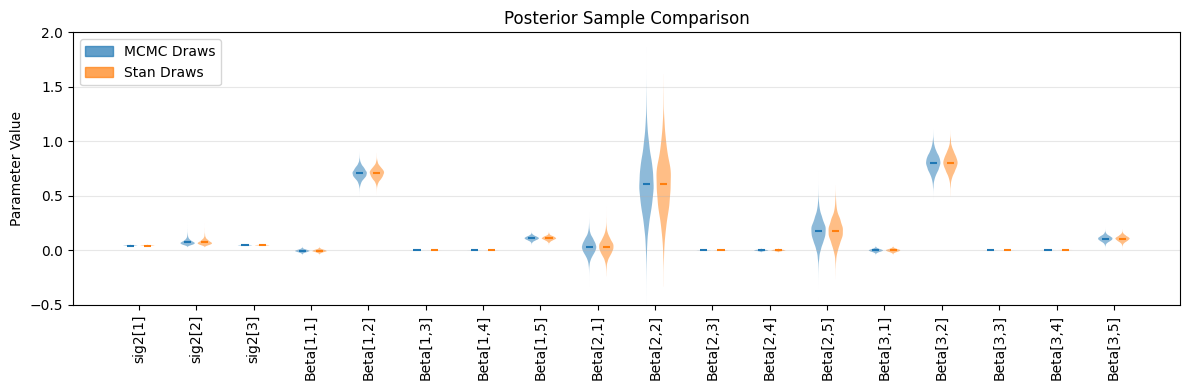

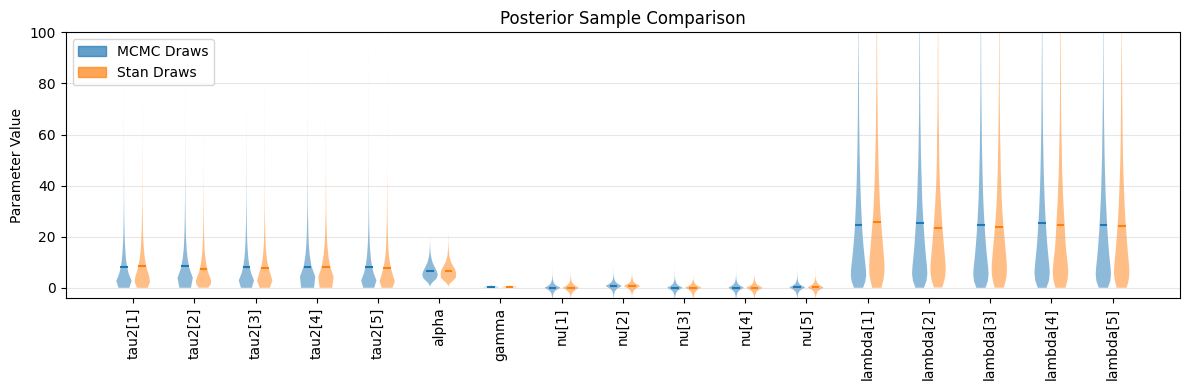

In [237]:
compare_posterior_draws(mcmc_draws_array[:18], stan_draws_array[:18], 
                        true_params=None, param_names=param_names[:18], figsize=(12, 4), y_lim=(-0.5, 2),
                        save_file="../figures/parameter_comparison_1.png")
compare_posterior_draws(mcmc_draws_array[18:], stan_draws_array[18:], 
                        true_params=None, param_names=param_names[18:], figsize=(12, 4), y_lim=(-4, 100),
                        save_file="../figures/parameter_comparison_2.png")

Diagnostics justifying the computations:

In [25]:
mcmc_ess = np.array([az.ess(np.hstack((draws1, draws2))) for draws1, draws2 in zip(mcmc_draws_array_1, mcmc_draws_array_2)])
stan_ess = np.array([az.ess(draws.values) for draws in stan_draws_array])
mcmc_rhat = np.array([az.rhat(np.vstack((draws1, draws2))) for draws1, draws2 in zip(mcmc_draws_array_1, mcmc_draws_array_2)])
stan_rhat = np.array([az.rhat(draws.values.reshape(2, -1)) for draws in stan_draws_array])
print(mcmc_ess.min(), mcmc_ess.max())
print(mcmc_rhat.min(), mcmc_rhat.max())
print(stan_ess.min(), stan_ess.max())
print(stan_rhat.min(), stan_rhat.max())

3785.524465706923 58985.92331521203
0.9999727923831294 1.0004751326056842
1.3062785623134592 4303.914244393067
1.0001993672148377 2.2388899854498967


After chopping of burn-in periods, all of the trace plots looked appropriate (like hairy-caterpillars oscillating around the mean). We ran very long chains (30,000+ iterations), ran multiple chains with varied starting positions, and the posterior distributions did not seem to change or deviate over time, which is a good indication of convergence. We were able to attain an effective sample size of at least 1,000 for each parameter, though we did have to run long chains to do this because of the large number of parameters. For our one hybrid Metropolis-Hastings sampler for $\alpha$, the acceptance rate varied between 0.4 and 0.65.

Simulate data for a particular storm (for the slides):

Date         2010-06-01
Basin                AL
LAT                16.4
LON               -83.1
AL                  1.0
CP                  0.0
EP                  0.0
VMAX12             40.0
MSLP12           1004.0
POT12             103.0
VMPI12            143.0
VGRAD0-6            0.0
VGRAD6-12      1.666667
VMAX36             55.0
ONI               -0.66
logVMAX12      3.688879
logMSLP12      6.911747
logPOT12       4.634729
logVMAX36      4.007333
logVMPI12      4.962845
BasinIDX              0
Name: 21, dtype: object


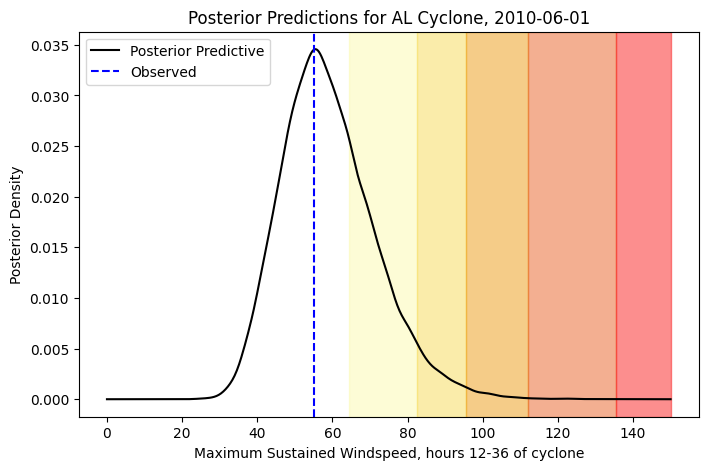

In [222]:
# pick a specific cyclone to model
# idx = data["Date"].argmax()
target_val = data["VMAX36"].quantile(0.75)
idx = (data["VMAX36"] - target_val).abs().idxmin()
cyclone = data.iloc[idx]
cyclone_X = X[idx]
cyclone_W = W[idx]
cyclone_basin = 0
print(cyclone)

# generate posterior predictive draws for this cyclone (using MCMC samples)
n = 30_000 - burn_in
ppd_W = np.empty(n)
for i in range(n):
    mean = MCMCSampler.Beta_draws[burn_in+i, cyclone_basin, :] @ cyclone_X
    var = MCMCSampler.sig2_draws[burn_in+i, cyclone_basin]
    ppd_W[i] = stats.norm.rvs(loc=mean, scale=np.sqrt(var))

# KDE plot
kde = stats.gaussian_kde(np.exp(ppd_W))
x_grid = np.linspace(0, 150, 500)

fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111)

ax.plot(x_grid, kde(x_grid), color="black", label="Posterior Predictive")
ax.axvline(np.exp(cyclone_W), color="blue", linestyle="--", label="Observed")
ax.set_xlabel("Maximum Sustained Windspeed, hours 12-36 of cyclone")
ax.set_ylabel("Posterior Density")
ax.set_title("Posterior Predictions for AL Cyclone, 2010-06-01")

# color in the different severity regions
ax.axvspan(64.3, 82.5, color='#fcfaae', alpha=0.5)
ax.axvspan(82.5, 95.5, color='#f7da57', alpha=0.5)
ax.axvspan(95.5, 112.1, color='#ed9a13', alpha=0.5)
ax.axvspan(112.1, 135.5, color='#e86025', alpha=0.5)
ax.axvspan(135.5, 150, color='#fa1e1e', alpha=0.5)

plt.legend(loc="upper left")
plt.show()

In [224]:
# pick a specific cyclone to model
# idx = data["Date"].argmax()
idx = data["VMAX36"].argmax()
cyclone = data.iloc[idx]
cyclone_X = X[idx]
cyclone_W = W[idx]
cyclone_basin = 0

In [225]:
# generate posterior predictive draws for this cyclone (using MCMC samples)
n = 30_000 - burn_in
ppd_W = np.empty(n)
for i in range(n):
    mean = MCMCSampler.Beta_draws[burn_in+i, cyclone_basin, :] @ cyclone_X
    var = MCMCSampler.sig2_draws[burn_in+i, cyclone_basin]
    ppd_W[i] = stats.norm.rvs(loc=mean, scale=np.sqrt(var))

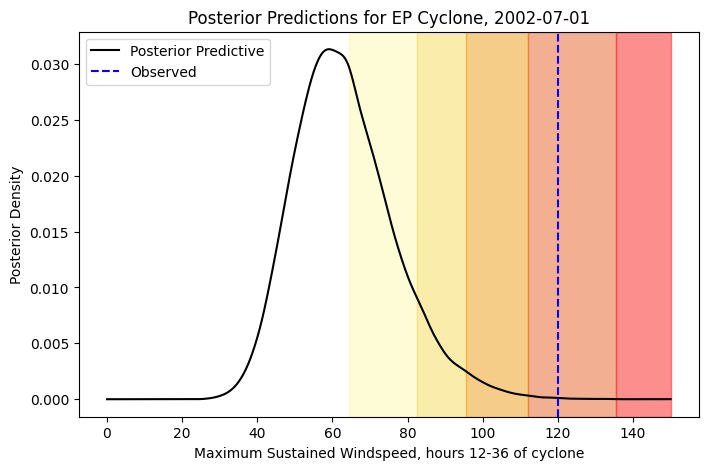

In [226]:
kde = stats.gaussian_kde(np.exp(ppd_W))
x_grid = np.linspace(0, 150, 500)

fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111)

ax.plot(x_grid, kde(x_grid), color="black", label="Posterior Predictive")
ax.axvline(np.exp(cyclone_W), color="blue", linestyle="--", label="Observed")
ax.set_xlabel("Maximum Sustained Windspeed, hours 12-36 of cyclone")
ax.set_ylabel("Posterior Density")
ax.set_title("Posterior Predictions for EP Cyclone, 2002-07-01")

# color in the different severity regions
ax.axvspan(64.3, 82.5, color='#fcfaae', alpha=0.5)
ax.axvspan(82.5, 95.5, color='#f7da57', alpha=0.5)
ax.axvspan(95.5, 112.1, color='#ed9a13', alpha=0.5)
ax.axvspan(112.1, 135.5, color='#e86025', alpha=0.5)
ax.axvspan(135.5, 150, color='#fa1e1e', alpha=0.5)

plt.legend(loc="upper left")
plt.show()